In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import json, joblib, warnings
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")
np.random.seed(42)
pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")
BLUE, CORAL, GREEN = "#4C72B0", "#DD8452", "#55A868"

print("✅ Imports ready")

✅ Imports ready


In [2]:
df = pd.read_csv("/content/AmesHousing.csv")

# Drop identifiers — row number and parcel ID are not features
df.drop(columns=["Order", "PID"], inplace=True, errors="ignore")
df["SalePrice"] = pd.to_numeric(df["SalePrice"], errors="coerce")

print(f"Shape           : {df.shape}")
print(f"Numeric cols    : {df.select_dtypes('number').shape[1]}")
print(f"Categorical cols: {df.select_dtypes('object').shape[1]}")
print()
print("Column names (first 20):", list(df.columns[:20]))
print()
print("First 3 rows:")
print(df.head(3))

Shape           : (2930, 80)
Numeric cols    : 37
Categorical cols: 43

Column names (first 20): ['MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area', 'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type', 'House Style', 'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add']

First 3 rows:
   MS SubClass MS Zoning  Lot Frontage  Lot Area Street Alley Lot Shape  \
0           20        RL         141.0     31770   Pave   NaN       IR1   
1           20        RH          80.0     11622   Pave   NaN       Reg   
2           20        RL          81.0     14267   Pave   NaN       IR1   

  Land Contour Utilities Lot Config Land Slope Neighborhood Condition 1  \
0          Lvl    AllPub     Corner        Gtl        NAmes        Norm   
1          Lvl    AllPub     Inside        Gtl        NAmes       Feedr   
2          Lvl    AllPub     Corner        Gtl        NAmes        Norm   

  

SalePrice statistics:
count      $2,930
mean     $180,796
std       $79,887
min       $12,789
25%      $129,500
50%      $160,000
75%      $213,500
max      $755,000

Skewness : 1.744
Kurtosis : 5.119


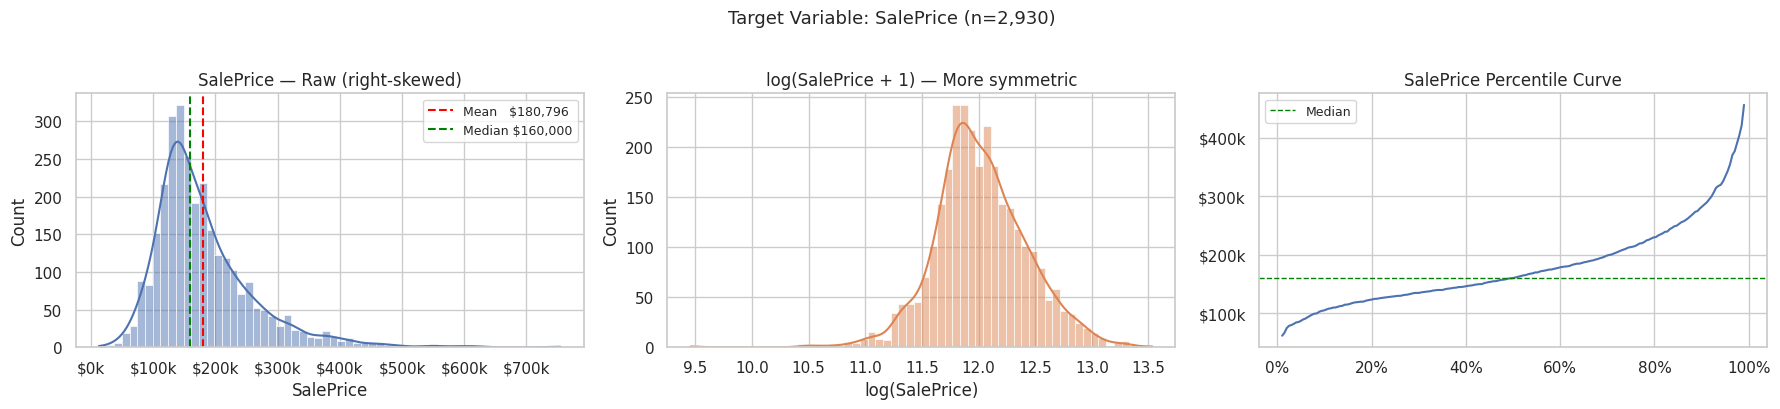

In [3]:
print("SalePrice statistics:")
print(df["SalePrice"].describe().apply(lambda x: f"${x:,.0f}").to_string())
print(f"\nSkewness : {df['SalePrice'].skew():.3f}")
print(f"Kurtosis : {df['SalePrice'].kurt():.3f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Raw distribution
sns.histplot(df["SalePrice"], bins=60, kde=True, ax=axes[0], color=BLUE)
axes[0].axvline(df["SalePrice"].mean(),   color="red",   ls="--", lw=1.5,
                label=f"Mean   ${df['SalePrice'].mean():,.0f}")
axes[0].axvline(df["SalePrice"].median(), color="green", ls="--", lw=1.5,
                label=f"Median ${df['SalePrice'].median():,.0f}")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
axes[0].set_title("SalePrice — Raw (right-skewed)")
axes[0].legend(fontsize=9)

# Log-transformed
sns.histplot(np.log1p(df["SalePrice"]), bins=60, kde=True, ax=axes[1], color=CORAL)
axes[1].set_title("log(SalePrice + 1) — More symmetric")
axes[1].set_xlabel("log(SalePrice)")

# Percentile curve
percs = np.linspace(1, 99, 200)
axes[2].plot(percs, np.percentile(df["SalePrice"].dropna(), percs), color=BLUE)
axes[2].axhline(df["SalePrice"].median(), color="green", ls="--", lw=1, label="Median")
axes[2].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
axes[2].set_title("SalePrice Percentile Curve")
axes[2].legend(fontsize=9)

plt.suptitle("Target Variable: SalePrice (n=2,930)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Columns with missing values: 27 / 80
                count   pct
Pool QC          2917  99.6
Misc Feature     2824  96.4
Alley            2732  93.2
Fence            2358  80.5
Mas Vnr Type     1775  60.6
Fireplace Qu     1422  48.5
Lot Frontage      490  16.7
Garage Qual       159   5.4
Garage Yr Blt     159   5.4
Garage Type       157   5.4
Garage Finish     159   5.4
Garage Cond       159   5.4
Bsmt Exposure      83   2.8
BsmtFin Type 2     81   2.8
Bsmt Cond          80   2.7
Bsmt Qual          80   2.7
BsmtFin Type 1     80   2.7
Mas Vnr Area       23   0.8
Bsmt Full Bath      2   0.1
Bsmt Half Bath      2   0.1
BsmtFin SF 1        1   0.0
BsmtFin SF 2        1   0.0
Electrical          1   0.0
Total Bsmt SF       1   0.0
Bsmt Unf SF         1   0.0
Garage Area         1   0.0
Garage Cars         1   0.0


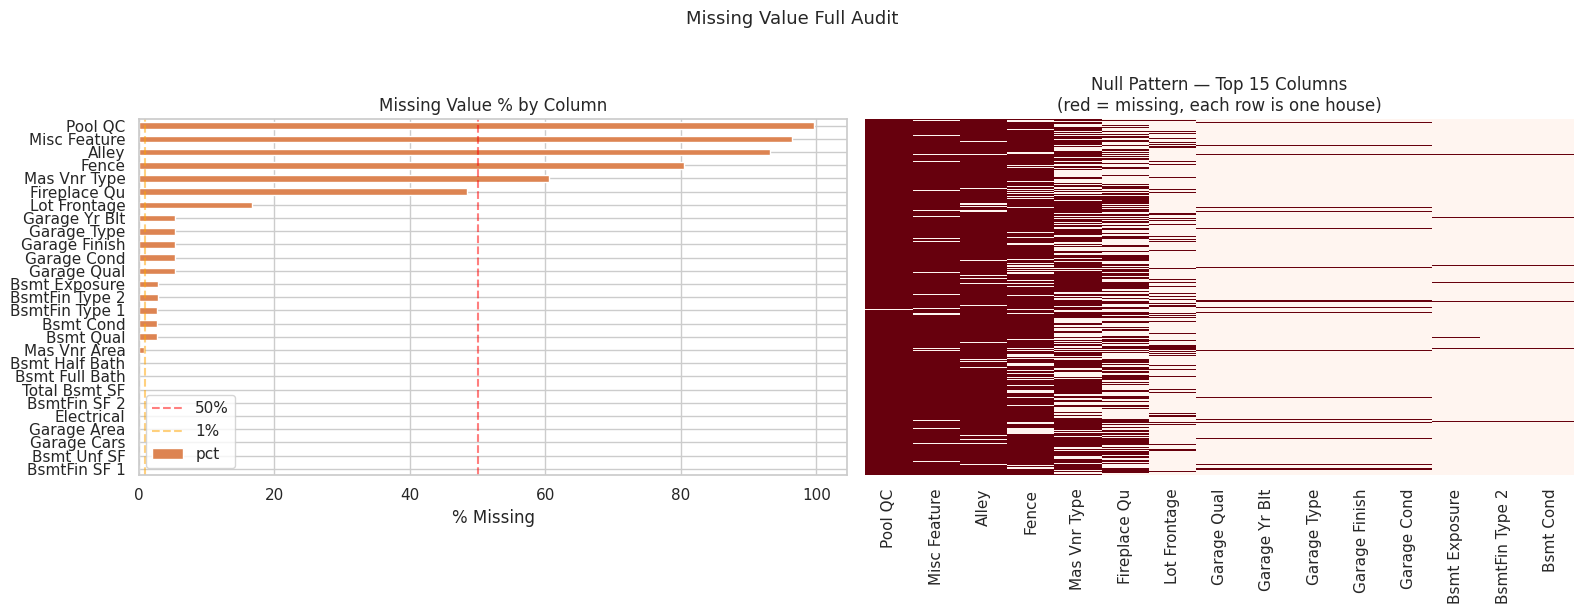

In [4]:
null_counts = df.isnull().sum()
null_pct    = (null_counts / len(df) * 100).round(1)
null_df     = (pd.DataFrame({"count": null_counts, "pct": null_pct})
               .query("count > 0")
               .sort_values("pct", ascending=False))

print(f"Columns with missing values: {len(null_df)} / {df.shape[1]}")
print(null_df.to_string())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

null_df["pct"].sort_values().plot(kind="barh", ax=axes[0], color=CORAL, edgecolor="white")
axes[0].axvline(50, color="red", ls="--", alpha=0.5, label="50%")
axes[0].axvline(1,  color="orange", ls="--", alpha=0.5, label="1%")
axes[0].set_xlabel("% Missing")
axes[0].set_title("Missing Value % by Column")
axes[0].legend()

top15 = null_df.head(15).index.tolist()
sns.heatmap(df[top15].isnull(), cbar=False, yticklabels=False,
            cmap="Reds", ax=axes[1])
axes[1].set_title("Null Pattern — Top 15 Columns\n(red = missing, each row is one house)")

plt.suptitle("Missing Value Full Audit", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


Numeric features: 36

Top 15 by |correlation| with SalePrice:
Overall Qual      0.799
Gr Liv Area       0.707
Garage Cars       0.648
Garage Area       0.640
Total Bsmt SF     0.632
1st Flr SF        0.622
Year Built        0.558
Full Bath         0.546
Year Remod/Add    0.533
Garage Yr Blt     0.509
Mas Vnr Area      0.502
TotRms AbvGrd     0.495
Fireplaces        0.475
BsmtFin SF 1      0.433
Lot Frontage      0.340


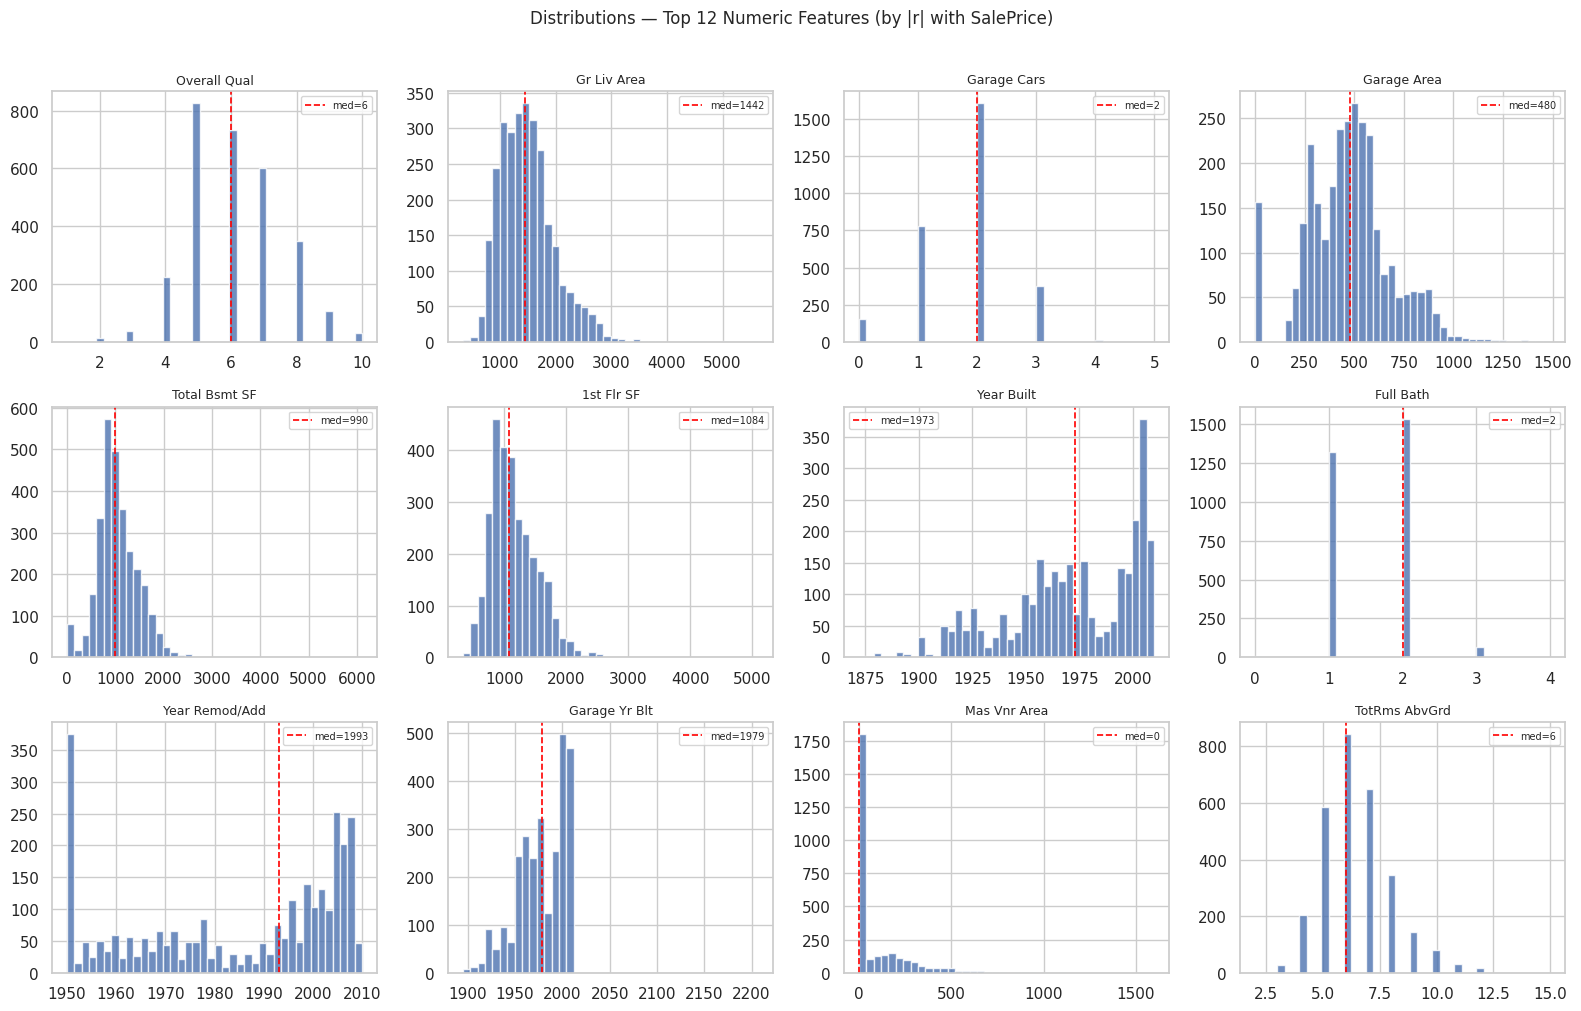

In [5]:
num_cols = df.select_dtypes("number").columns.drop("SalePrice").tolist()
X_filled_scan = df[num_cols].apply(lambda c: c.fillna(c.median()))
corr_preview  = X_filled_scan.corrwith(df["SalePrice"]).abs().sort_values(ascending=False)

print(f"Numeric features: {len(num_cols)}")
print("\nTop 15 by |correlation| with SalePrice:")
print(corr_preview.head(15).round(3).to_string())

top12 = corr_preview.head(12).index.tolist()
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for i, col in enumerate(top12):
    ax  = axes[i // 4][i % 4]
    vals = df[col].dropna()
    ax.hist(vals, bins=40, color=BLUE, edgecolor="white", alpha=0.8)
    ax.axvline(vals.median(), color="red", ls="--", lw=1.2,
               label=f"med={vals.median():.0f}")
    ax.set_title(col, fontsize=9)
    ax.legend(fontsize=7)
plt.suptitle("Distributions — Top 12 Numeric Features (by |r| with SalePrice)",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


Categorical features: 43
Neighborhood      28
Exterior 2nd      17
Exterior 1st      16
Sale Type         10
Condition 1        9
House Style        8
Functional         8
Roof Matl          8
Condition 2        8
MS Zoning          7
Roof Style         6
BsmtFin Type 1     6
Sale Condition     6
Heating            6
Foundation         6
Garage Type        6
BsmtFin Type 2     6
Lot Config         5
Kitchen Qual       5
Misc Feature       5
Garage Cond        5
Garage Qual        5
Exter Cond         5
Fireplace Qu       5
Bsmt Cond          5
Bldg Type          5
Bsmt Qual          5
Heating QC         5
Electrical         5
Bsmt Exposure      4
Exter Qual         4
Land Contour       4
Lot Shape          4
Mas Vnr Type       4
Pool QC            4
Fence              4
Garage Finish      3
Land Slope         3
Utilities          3
Paved Drive        3
Alley              2
Street             2
Central Air        2


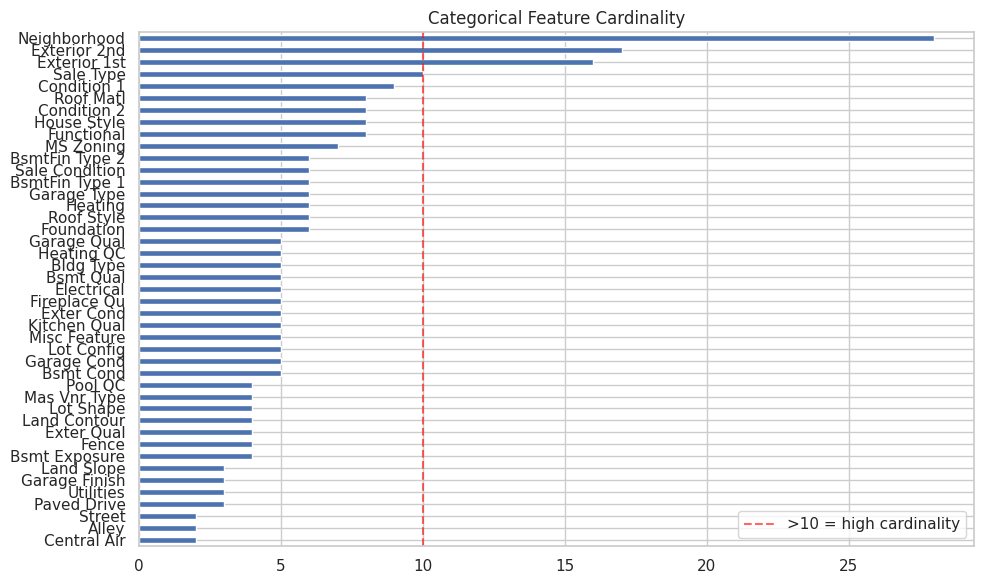

In [6]:
cat_cols    = df.select_dtypes("object").columns.tolist()
cardinality = df[cat_cols].nunique().sort_values(ascending=False)

print(f"Categorical features: {len(cat_cols)}")
print(cardinality.to_string())

fig, ax = plt.subplots(figsize=(10, 6))
cardinality.sort_values().plot(kind="barh", ax=ax, color=BLUE)
ax.axvline(10, color="red", ls="--", alpha=0.6, label=">10 = high cardinality")
ax.set_title("Categorical Feature Cardinality")
ax.legend()
plt.tight_layout()
plt.show()

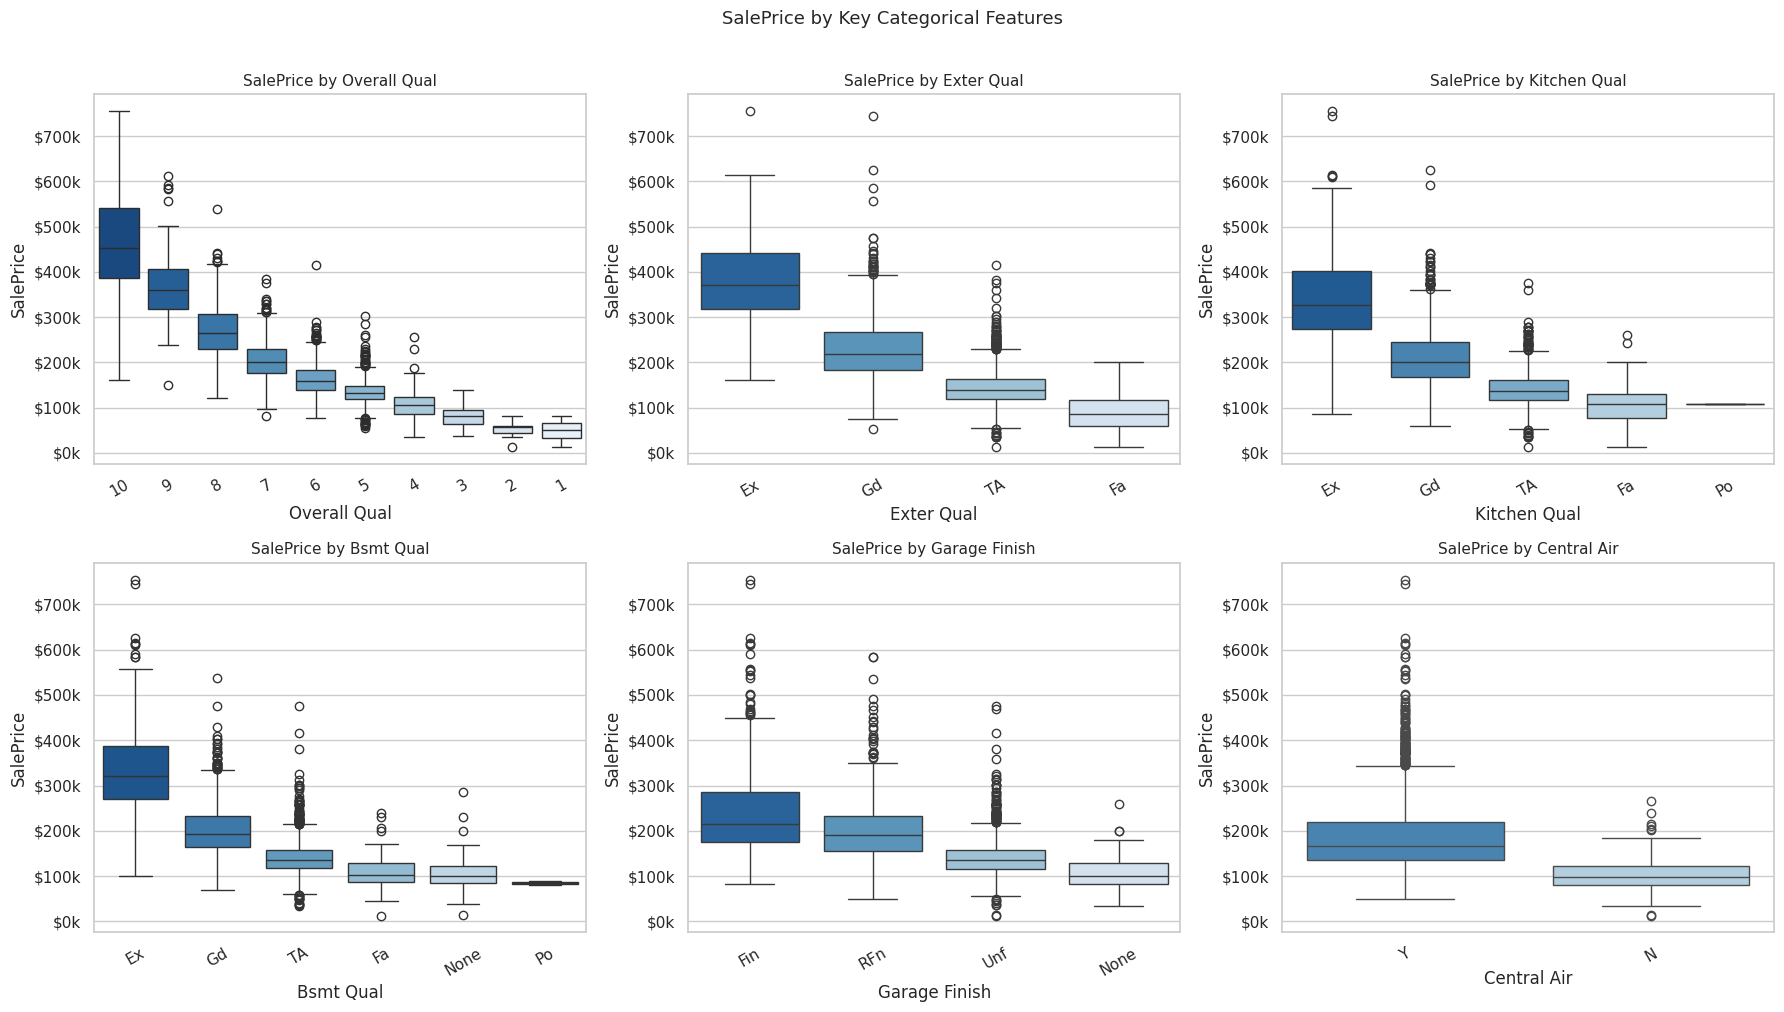

In [7]:
key_cats = ["Overall Qual", "Exter Qual", "Kitchen Qual",
            "Bsmt Qual", "Garage Finish", "Central Air"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(key_cats):
    plot_df = pd.DataFrame({
        col:         df[col].fillna("None"),
        "SalePrice": df["SalePrice"],
    })
    order = plot_df.groupby(col)["SalePrice"].median().sort_values(ascending=False).index
    sns.boxplot(data=plot_df, x=col, y="SalePrice",
                order=order, ax=axes[i], palette="Blues_r")
    axes[i].set_title(f"SalePrice by {col}", fontsize=11)
    axes[i].yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
    axes[i].tick_params(axis="x", rotation=30)

plt.suptitle("SalePrice by Key Categorical Features", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

Neighborhood stats (count + price):
              count      mean    median
Neighborhood                           
NAmes           443  145097.0  140000.0
CollgCr         267  201803.0  200000.0
OldTown         239  123992.0  119900.0
Edwards         194  130843.0  125000.0
Somerst         182  229707.0  225500.0
NridgHt         166  322018.0  317750.0
Gilbert         165  190647.0  183000.0
Sawyer          151  136751.0  135000.0
NWAmes          131  188407.0  181000.0
SawyerW         125  184070.0  180000.0
Mitchel         114  162227.0  153500.0
BrkSide         108  124756.0  126750.0
Crawfor         103  207551.0  200624.0
IDOTRR           93  103753.0  106500.0
Timber           72  246600.0  232106.0
NoRidge          71  330319.0  302000.0
StoneBr          51  324229.0  319000.0
SWISU            48  135072.0  136200.0
ClearCr          44  208662.0  197500.0
MeadowV          37   95756.0   88250.0
BrDale           30  105608.0  106000.0
Blmngtn          28  196662.0  191500.0
Veen

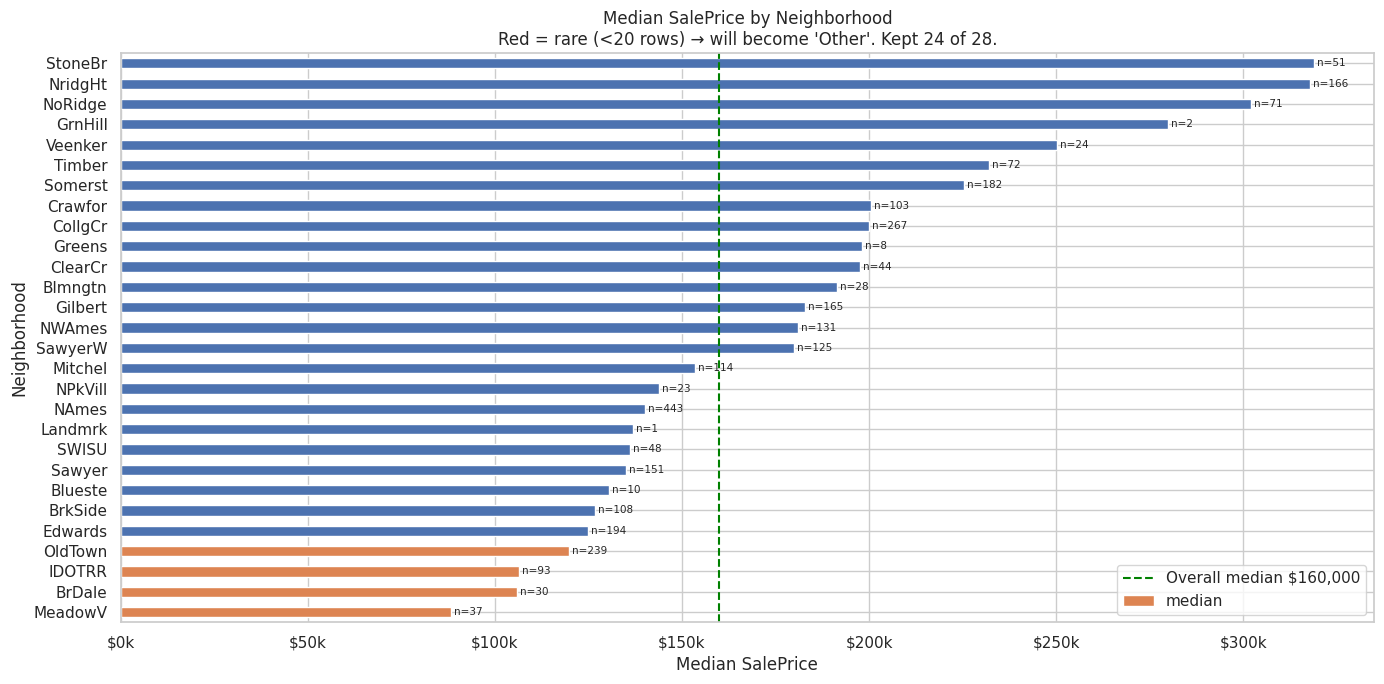

In [8]:
nbhd_stats = (
    df.groupby("Neighborhood")["SalePrice"]
    .agg(count="count", mean="mean", median="median")
    .sort_values("count", ascending=False)
    .round(0)
)

print("Neighborhood stats (count + price):")
print(nbhd_stats.to_string())

RARE_THRESHOLD = 20   # only group neighborhoods with < 20 rows

# Which neighborhoods fall below the threshold?
rare_nbhds   = nbhd_stats[nbhd_stats["count"] < RARE_THRESHOLD].index.tolist()
common_nbhds = nbhd_stats[nbhd_stats["count"] >= RARE_THRESHOLD].index.tolist()

print(f"\n--- Grouping decision (threshold = {RARE_THRESHOLD} rows) ---")
print(f"Rare neighborhoods → 'Other': {rare_nbhds}  (n rows: {[int(nbhd_stats.loc[n,'count']) for n in rare_nbhds]})")
print(f"Kept as-is: {len(common_nbhds)} neighborhoods")
print(f"Final OHE count: {len(common_nbhds) + 1}  (was 28)")

# Visualise
fig, ax = plt.subplots(figsize=(14, 7))
colors = [CORAL if n in rare_nbhds else BLUE for n in nbhd_stats.index]
nbhd_stats["median"].sort_values().plot(kind="barh", ax=ax, color=colors[::-1])
ax.axvline(df["SalePrice"].median(), color="green", ls="--", lw=1.5,
           label=f"Overall median ${df['SalePrice'].median():,.0f}")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
ax.set_title(f"Median SalePrice by Neighborhood\n"
             f"Red = rare (<{RARE_THRESHOLD} rows) → will become 'Other'. "
             f"Kept {len(common_nbhds)} of 28.")
ax.set_xlabel("Median SalePrice")
ax.legend()
for i, (nbhd, row) in enumerate(nbhd_stats.sort_values("median").iterrows()):
    ax.text(row["median"] + 800, i, f"n={int(row['count'])}", va="center", fontsize=7.5)
plt.tight_layout()
plt.show()

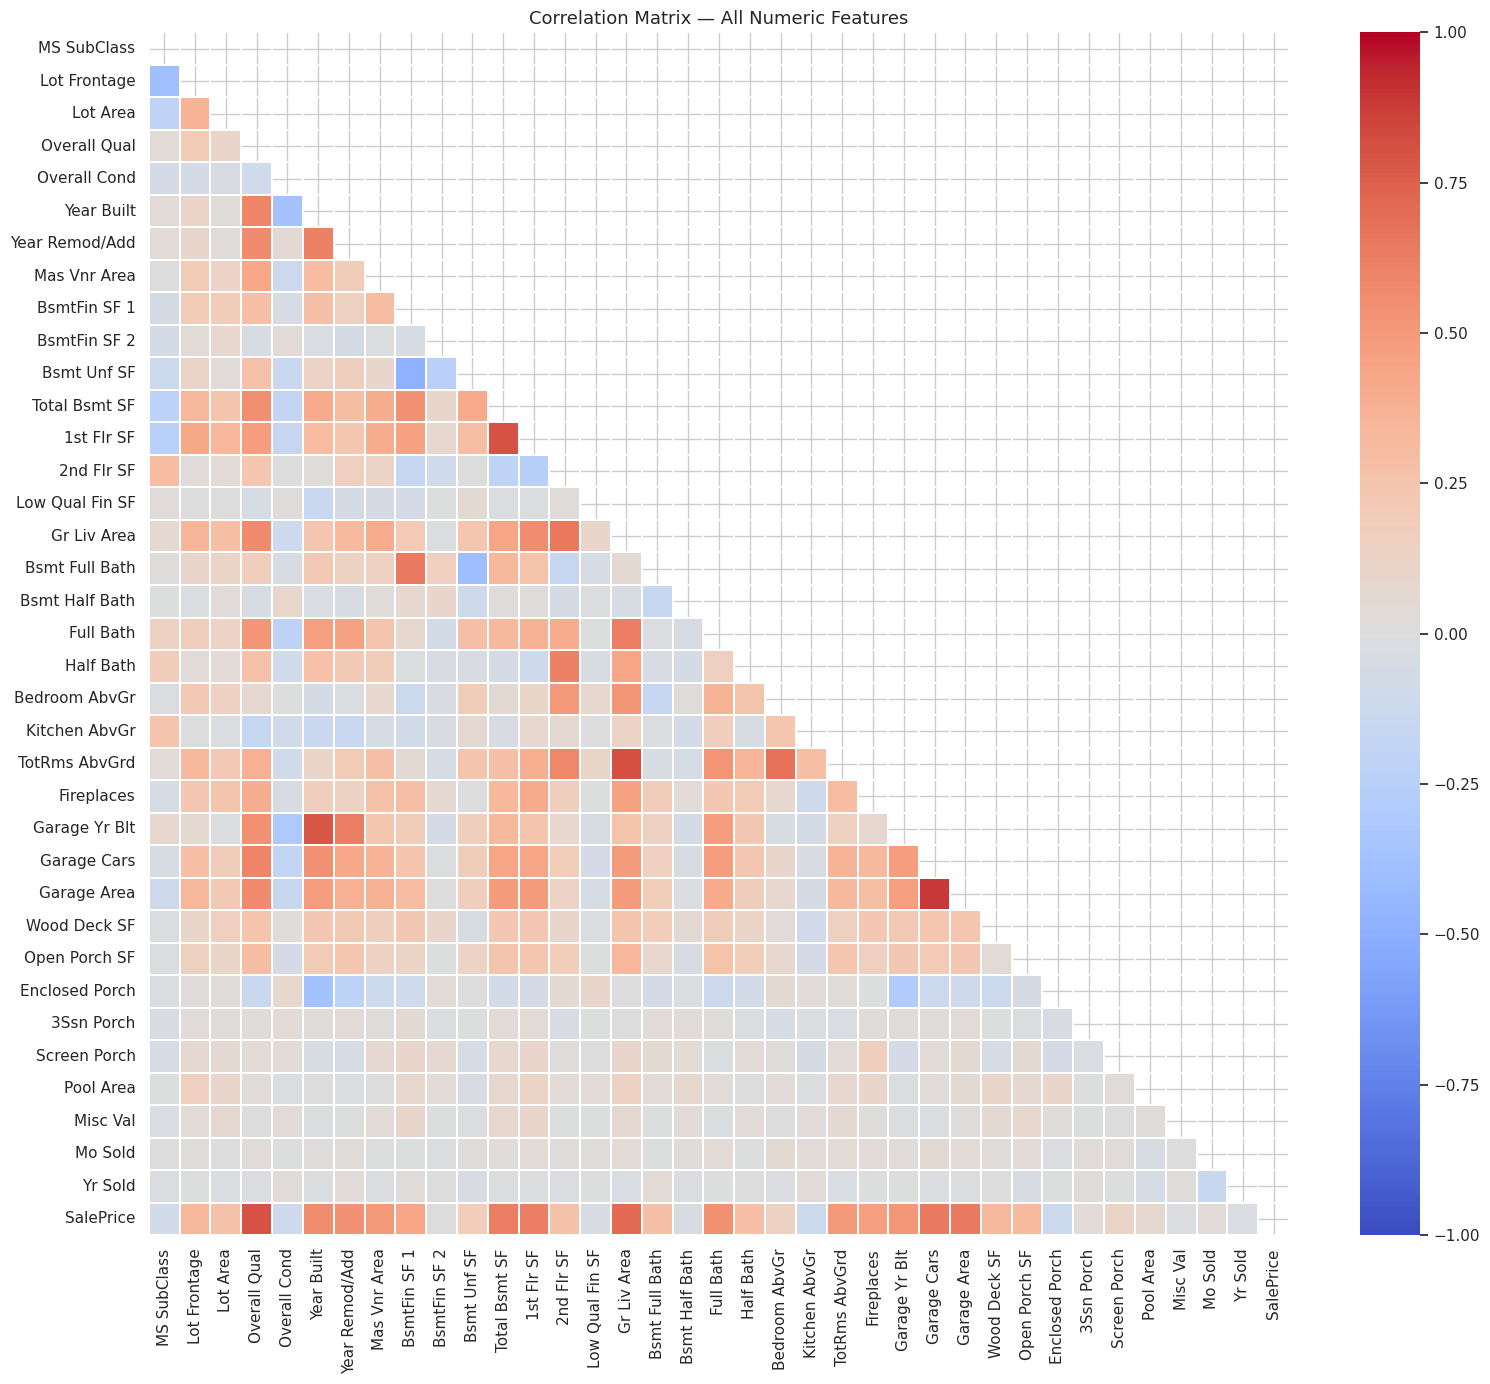

Features with |r| > 0.5 vs SalePrice:
SalePrice         1.000000
Overall Qual      0.799262
Gr Liv Area       0.706780
Garage Cars       0.647812
Garage Area       0.640381
Total Bsmt SF     0.632164
1st Flr SF        0.621676
Year Built        0.558426
Full Bath         0.545604
Year Remod/Add    0.532974
Garage Yr Blt     0.508882
Mas Vnr Area      0.502196


In [9]:
corr_matrix = df[num_cols + ["SalePrice"]].fillna(
    df[num_cols + ["SalePrice"]].median()
).corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(corr_matrix, mask=mask, cmap="coolwarm", center=0,
            annot=False, linewidths=0.2, ax=ax, vmin=-1, vmax=1)
ax.set_title("Correlation Matrix — All Numeric Features", fontsize=13)
plt.tight_layout()
plt.show()

strong = corr_matrix["SalePrice"].abs().sort_values(ascending=False)
print("Features with |r| > 0.5 vs SalePrice:")
print(strong[strong > 0.5].to_string())

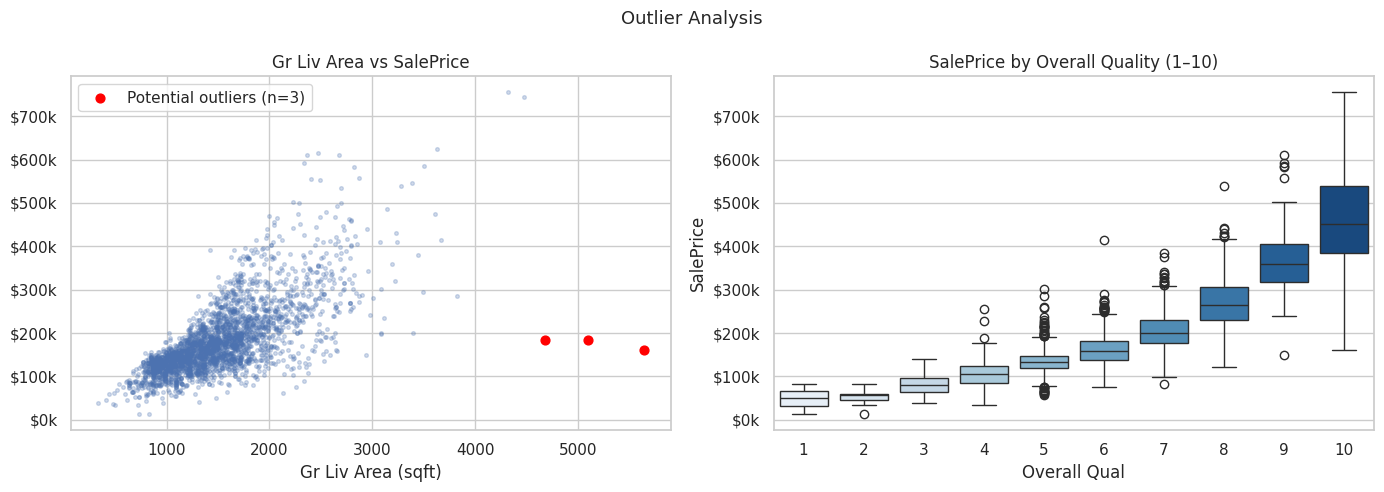

Note: outliers kept — legitimate sales, not data entry errors.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gr Liv Area vs SalePrice
axes[0].scatter(df["Gr Liv Area"], df["SalePrice"],
                alpha=0.25, s=7, color=BLUE)
outliers = df[(df["Gr Liv Area"] > 4000) & (df["SalePrice"] < 300000)]
axes[0].scatter(outliers["Gr Liv Area"], outliers["SalePrice"],
                color="red", s=40, zorder=5,
                label=f"Potential outliers (n={len(outliers)})")
axes[0].set_xlabel("Gr Liv Area (sqft)")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
axes[0].set_title("Gr Liv Area vs SalePrice")
axes[0].legend()

# Overall Qual vs SalePrice
sns.boxplot(data=df, x="Overall Qual", y="SalePrice", ax=axes[1], palette="Blues")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
axes[1].set_title("SalePrice by Overall Quality (1–10)")

plt.suptitle("Outlier Analysis", fontsize=13)
plt.tight_layout()
plt.show()

print("Note: outliers kept — legitimate sales, not data entry errors.")

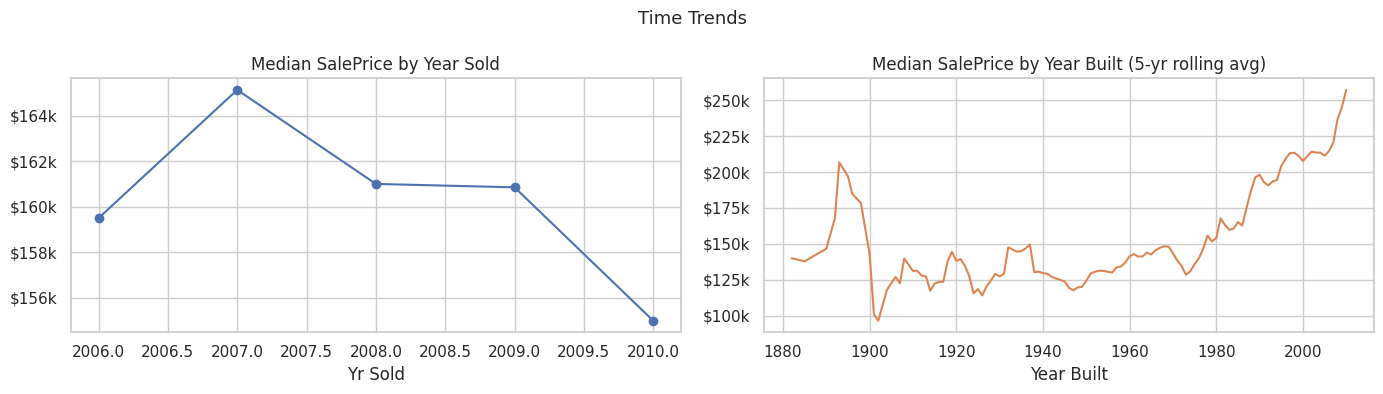

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df.groupby("Yr Sold")["SalePrice"].median().plot(
    ax=axes[0], marker="o", color=BLUE)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
axes[0].set_title("Median SalePrice by Year Sold")

df.groupby("Year Built")["SalePrice"].median().rolling(5).mean().plot(
    ax=axes[1], color=CORAL)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
axes[1].set_title("Median SalePrice by Year Built (5-yr rolling avg)")

plt.suptitle("Time Trends", fontsize=13)
plt.tight_layout()
plt.show()

Train :      1758 rows (60%)
Validation :  586 rows (20%)
Test :        586 rows (20%)


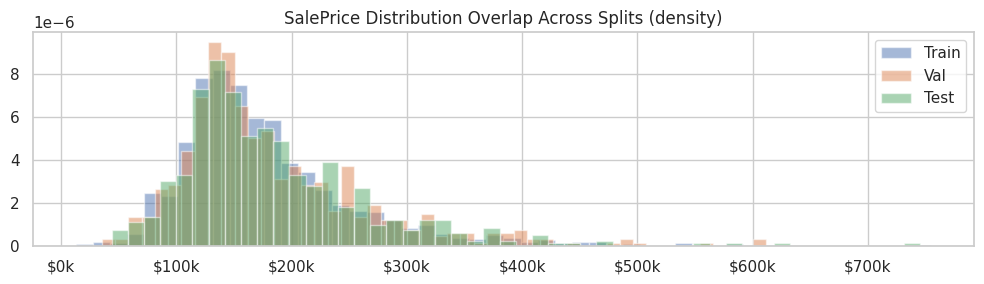


Medians — Train: $160,100  Val: $159,000  Test: $165,000


In [12]:
X = df.drop(columns=["SalePrice"])
y = df["SalePrice"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42)

total = len(df)
print(f"Train :      {len(X_train):4d} rows ({len(X_train)/total*100:.0f}%)")
print(f"Validation : {len(X_val):4d} rows ({len(X_val)/total*100:.0f}%)")
print(f"Test :       {len(X_test):4d} rows ({len(X_test)/total*100:.0f}%)")

# Balance check
fig, ax = plt.subplots(figsize=(10, 3))
for name, y_s, color in [("Train", y_train, BLUE),
                           ("Val",   y_val,   CORAL),
                           ("Test",  y_test,  GREEN)]:
    ax.hist(y_s, bins=50, alpha=0.5, density=True, label=name, color=color)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
ax.set_title("SalePrice Distribution Overlap Across Splits (density)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nMedians — Train: ${y_train.median():,.0f}  "
      f"Val: ${y_val.median():,.0f}  Test: ${y_test.median():,.0f}")

In [13]:
tr_nulls = X_train.isnull().sum()
tr_pct   = (tr_nulls / len(X_train) * 100).round(1)
tr_null_df = (pd.DataFrame({"count": tr_nulls, "pct": tr_pct,
                             "dtype": X_train.dtypes})
              .query("count > 0")
              .sort_values("pct", ascending=False))

print(f"Training set — columns with nulls: {len(tr_null_df)}")
print(tr_null_df.to_string())

Training set — columns with nulls: 26
                count   pct    dtype
Pool QC          1752  99.7   object
Misc Feature     1692  96.2   object
Alley            1636  93.1   object
Fence            1411  80.3   object
Mas Vnr Type     1055  60.0   object
Fireplace Qu      877  49.9   object
Lot Frontage      308  17.5  float64
Garage Yr Blt      99   5.6  float64
Garage Type        98   5.6   object
Garage Finish      99   5.6   object
Garage Cond        99   5.6   object
Garage Qual        99   5.6   object
Bsmt Exposure      44   2.5   object
Bsmt Cond          42   2.4   object
Bsmt Qual          42   2.4   object
BsmtFin Type 2     42   2.4   object
BsmtFin Type 1     42   2.4   object
Mas Vnr Area       12   0.7  float64
BsmtFin SF 1        1   0.1  float64
Bsmt Half Bath      1   0.1  float64
Total Bsmt SF       1   0.1  float64
Bsmt Full Bath      1   0.1  float64
BsmtFin SF 2        1   0.1  float64
Bsmt Unf SF         1   0.1  float64
Garage Area         1   0.1  float64


Top 20 by |Pearson correlation| with SalePrice (training set):
Overall Qual      0.791
Gr Liv Area       0.704
Garage Cars       0.642
Total Bsmt SF     0.642
Garage Area       0.631
1st Flr SF        0.624
Year Built        0.543
Full Bath         0.543
Year Remod/Add    0.511
Mas Vnr Area      0.508
Garage Yr Blt     0.491
TotRms AbvGrd     0.490
Fireplaces        0.470
BsmtFin SF 1      0.430
Wood Deck SF      0.346
Lot Frontage      0.328
Bsmt Full Bath    0.293
Half Bath         0.292
Open Porch SF     0.271
Lot Area          0.268


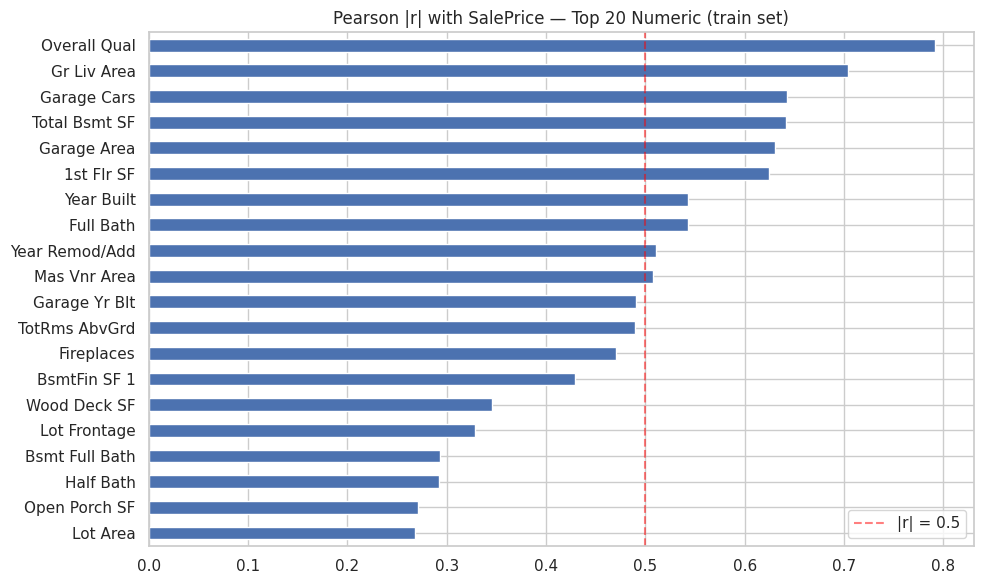

In [14]:
num_all = X_train.select_dtypes("number").columns.tolist()
X_tr_filled = X_train[num_all].apply(lambda c: c.fillna(c.median()))
corr_with_price = (X_tr_filled.corrwith(y_train)
                   .abs().sort_values(ascending=False))

print("Top 20 by |Pearson correlation| with SalePrice (training set):")
print(corr_with_price.head(20).round(3).to_string())

fig, ax = plt.subplots(figsize=(10, 6))
corr_with_price.head(20).sort_values().plot(kind="barh", ax=ax, color=BLUE)
ax.set_title("Pearson |r| with SalePrice — Top 20 Numeric (train set)")
ax.axvline(0.5, color="red", ls="--", alpha=0.5, label="|r| = 0.5")
ax.legend()
plt.tight_layout()
plt.show()

Top 20 by Random Forest importance:
Overall Qual      0.6357
Gr Liv Area       0.1077
1st Flr SF        0.0480
Full Bath         0.0360
Total Bsmt SF     0.0331
BsmtFin SF 1      0.0206
Lot Area          0.0129
Garage Cars       0.0114
Year Built        0.0107
Garage Area       0.0095
Kitchen Qual      0.0080
Bsmt Qual         0.0073
Mas Vnr Area      0.0070
Exter Qual        0.0057
Year Remod/Add    0.0053
2nd Flr SF        0.0047
TotRms AbvGrd     0.0045
Lot Frontage      0.0026
MS Zoning         0.0022
Bsmt Unf SF       0.0022


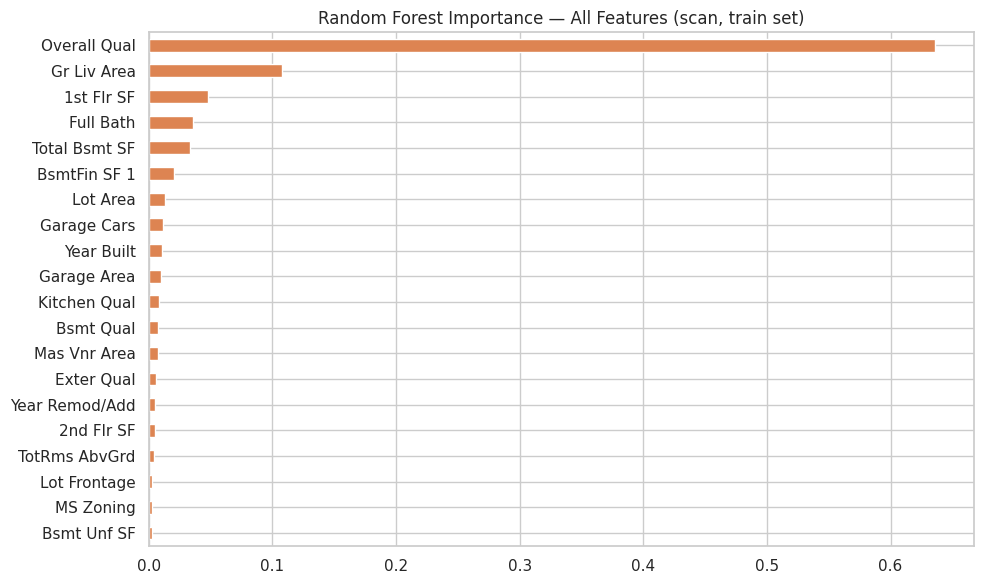

In [15]:
X_scan = X_train.copy()
for col in X_scan.select_dtypes("number").columns:
    X_scan[col] = X_scan[col].fillna(X_scan[col].median())
for col in X_scan.select_dtypes("object").columns:
    freq_map = X_scan[col].value_counts().to_dict()
    X_scan[col] = X_scan[col].map(freq_map).fillna(0).astype(int)

rf_scanner = RandomForestRegressor(n_estimators=100, max_depth=8,
                                   min_samples_leaf=10, random_state=42,
                                   n_jobs=-1)
rf_scanner.fit(X_scan, y_train)

imp_all = (pd.Series(rf_scanner.feature_importances_, index=X_scan.columns)
           .sort_values(ascending=False))

print("Top 20 by Random Forest importance:")
print(imp_all.head(20).round(4).to_string())

fig, ax = plt.subplots(figsize=(10, 6))
imp_all.head(20).sort_values().plot(kind="barh", ax=ax, color=CORAL)
ax.set_title("Random Forest Importance — All Features (scan, train set)")
plt.tight_layout()
plt.show()


In [16]:
rank_table = (
    pd.concat([
        corr_with_price.rank(ascending=False).rename("corr_rank"),
        imp_all.rank(ascending=False).rename("rf_rank"),
    ], axis=1)
    .dropna()
    .assign(avg_rank=lambda d: (d["corr_rank"] + d["rf_rank"]) / 2)
    .sort_values("avg_rank")
)

print("Combined rank table (lower avg_rank = better):")
print(rank_table.head(25).round(1).to_string())

Combined rank table (lower avg_rank = better):
                corr_rank  rf_rank  avg_rank
Overall Qual          1.0      1.0       1.0
Gr Liv Area           2.0      2.0       2.0
Total Bsmt SF         4.0      5.0       4.5
1st Flr SF            6.0      3.0       4.5
Garage Cars           3.0      8.0       5.5
Full Bath             8.0      4.0       6.0
Garage Area           5.0     10.0       7.5
Year Built            7.0      9.0       8.0
BsmtFin SF 1         14.0      6.0      10.0
Mas Vnr Area         10.0     13.0      11.5
Year Remod/Add        9.0     15.0      12.0
Lot Area             20.0      7.0      13.5
TotRms AbvGrd        12.0     17.0      14.5
Garage Yr Blt        11.0     22.0      16.5
Lot Frontage         16.0     18.0      17.0
2nd Flr SF           21.0     16.0      18.5
Bsmt Unf SF          22.0     20.0      21.0
Wood Deck SF         15.0     27.0      21.0
Open Porch SF        19.0     25.0      22.0
Bsmt Full Bath       17.0     29.0      23.0
Fireplac

In [17]:
SELECTED_FEATURES = [
    "Overall Qual",   # numeric int 1-10
    "Gr Liv Area",    # numeric sqft
    "Garage Cars",    # numeric (1 null → structural 0)
    "Total Bsmt SF",  # numeric sqft (1 null → structural 0)
    "Full Bath",      # numeric int
    "Year Built",     # numeric int
    "Lot Area",       # numeric sqft
    "Neighborhood",   # nominal categorical — 28 unique (4 rare → grouped)
    "Exter Qual",     # ordinal categorical Fa/TA/Gd/Ex
    "Kitchen Qual",   # ordinal categorical Po/Fa/TA/Gd/Ex
]

print(f"✅ Selected {len(SELECTED_FEATURES)} features:\n")
for feat in SELECTED_FEATURES:
    dtype  = X_train[feat].dtype
    nuniq  = X_train[feat].nunique()
    n_null = X_train[feat].isnull().sum()
    flag   = "  ← structural 0 fill" if n_null > 0 else ""
    print(f"  {feat:<20}  dtype={str(dtype):<10}  "
          f"unique={nuniq:4d}  train_nulls={n_null}{flag}")

✅ Selected 10 features:

  Overall Qual          dtype=int64       unique=  10  train_nulls=0
  Gr Liv Area           dtype=int64       unique= 964  train_nulls=0
  Garage Cars           dtype=float64     unique=   5  train_nulls=1  ← structural 0 fill
  Total Bsmt SF         dtype=float64     unique= 819  train_nulls=1  ← structural 0 fill
  Full Bath             dtype=int64       unique=   5  train_nulls=0
  Year Built            dtype=int64       unique= 113  train_nulls=0
  Lot Area              dtype=int64       unique=1284  train_nulls=0
  Neighborhood          dtype=object      unique=  28  train_nulls=0
  Exter Qual            dtype=object      unique=   4  train_nulls=0
  Kitchen Qual          dtype=object      unique=   4  train_nulls=0


In [18]:
RARE_THRESHOLD = 20

# Compute from training set ONLY (no leakage)
nbhd_train_counts = X_train["Neighborhood"].value_counts()

RARE_NEIGHBORHOODS   = nbhd_train_counts[nbhd_train_counts < RARE_THRESHOLD].index.tolist()
COMMON_NEIGHBORHOODS = nbhd_train_counts[nbhd_train_counts >= RARE_THRESHOLD].index.tolist()

print(f"Neighborhood grouping (threshold = {RARE_THRESHOLD} train rows):")
print(f"\n  Rare → 'Other': {RARE_NEIGHBORHOODS}")
for n in RARE_NEIGHBORHOODS:
    cnt = int(nbhd_train_counts.get(n, 0))
    print(f"    {n:<12}  n={cnt} in train")
print(f"\n  Kept ({len(COMMON_NEIGHBORHOODS)}) :")
for n in sorted(COMMON_NEIGHBORHOODS):
    cnt = int(nbhd_train_counts[n])
    print(f"    {n:<12}  n={cnt}")
print(f"\n  Final OHE: {len(COMMON_NEIGHBORHOODS) + 1} categories "
      f"({len(COMMON_NEIGHBORHOODS)} neighborhoods + 'Other')")


Neighborhood grouping (threshold = 20 train rows):

  Rare → 'Other': ['BrDale', 'Blmngtn', 'NPkVill', 'Greens', 'Blueste', 'GrnHill', 'Landmrk']
    BrDale        n=18 in train
    Blmngtn       n=15 in train
    NPkVill       n=10 in train
    Greens        n=5 in train
    Blueste       n=4 in train
    GrnHill       n=2 in train
    Landmrk       n=1 in train

  Kept (21) :
    BrkSide       n=65
    ClearCr       n=24
    CollgCr       n=158
    Crawfor       n=62
    Edwards       n=104
    Gilbert       n=97
    IDOTRR        n=56
    MeadowV       n=24
    Mitchel       n=70
    NAmes         n=273
    NWAmes        n=89
    NoRidge       n=43
    NridgHt       n=92
    OldTown       n=147
    SWISU         n=31
    Sawyer        n=95
    SawyerW       n=78
    Somerst       n=103
    StoneBr       n=30
    Timber        n=42
    Veenker       n=20

  Final OHE: 22 categories (21 neighborhoods + 'Other')


In [19]:
def group_rare_neighborhoods(series: pd.Series, rare_list: list,
                              other_label: str = "Other") -> pd.Series:
    """Replaces rare neighborhood names with other_label."""
    return series.where(~series.isin(rare_list), other=other_label)


X_train_sel = X_train[SELECTED_FEATURES].copy()
X_val_sel   = X_val[SELECTED_FEATURES].copy()
X_test_sel  = X_test[SELECTED_FEATURES].copy()

for X_s in [X_train_sel, X_val_sel, X_test_sel]:
    X_s["Neighborhood"] = group_rare_neighborhoods(
        X_s["Neighborhood"], RARE_NEIGHBORHOODS)

print("Neighborhood value counts after grouping (train set):")
vc = X_train_sel["Neighborhood"].value_counts()
print(vc.to_string())
print(f"\n'Other' in train: {vc.get('Other', 0)} rows")
print(f"'Other' in val:   {(X_val_sel['Neighborhood']=='Other').sum()} rows")
print(f"'Other' in test:  {(X_test_sel['Neighborhood']=='Other').sum()} rows")

Neighborhood value counts after grouping (train set):
Neighborhood
NAmes      273
CollgCr    158
OldTown    147
Edwards    104
Somerst    103
Gilbert     97
Sawyer      95
NridgHt     92
NWAmes      89
SawyerW     78
Mitchel     70
BrkSide     65
Crawfor     62
IDOTRR      56
Other       55
NoRidge     43
Timber      42
SWISU       31
StoneBr     30
MeadowV     24
ClearCr     24
Veenker     20

'Other' in train: 55 rows
'Other' in val:   22 rows
'Other' in test:  25 rows


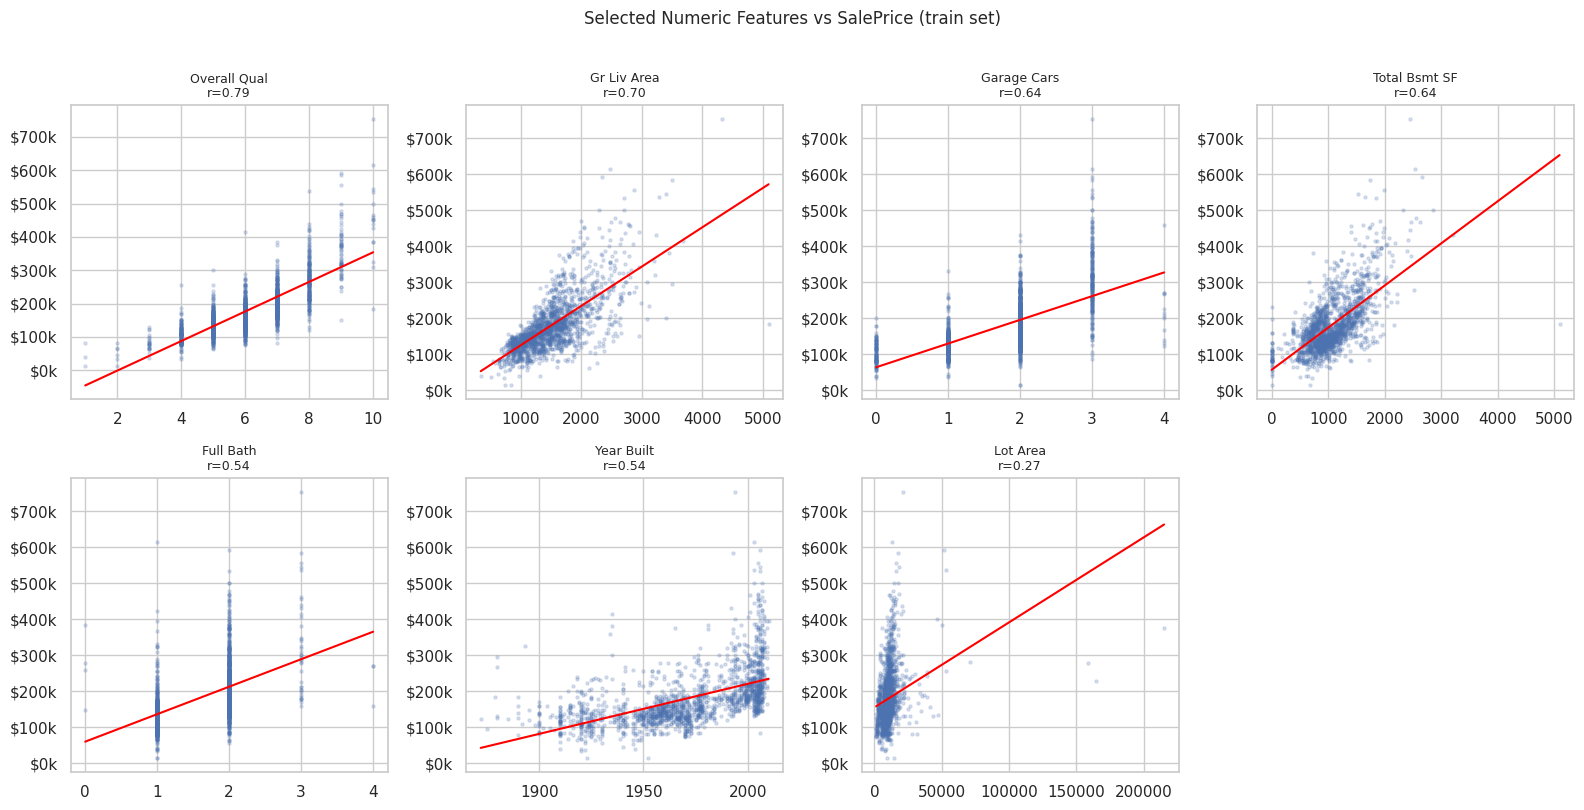

In [20]:
NUMERIC_SEL = ["Overall Qual","Gr Liv Area","Garage Cars",
               "Total Bsmt SF","Full Bath","Year Built","Lot Area"]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, col in enumerate(NUMERIC_SEL):
    r, c = i // 4, i % 4
    xv = X_train_sel[col].fillna(0)
    axes[r][c].scatter(xv, y_train, alpha=0.2, s=5, color=BLUE)
    z = np.polyfit(xv, y_train, 1)
    xs = np.linspace(xv.min(), xv.max(), 100)
    axes[r][c].plot(xs, np.poly1d(z)(xs), color="red", lw=1.5)
    rval = xv.corr(y_train)
    axes[r][c].set_title(f"{col}\nr={rval:.2f}", fontsize=9)
    axes[r][c].yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
axes[1][3].set_visible(False)
plt.suptitle("Selected Numeric Features vs SalePrice (train set)", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

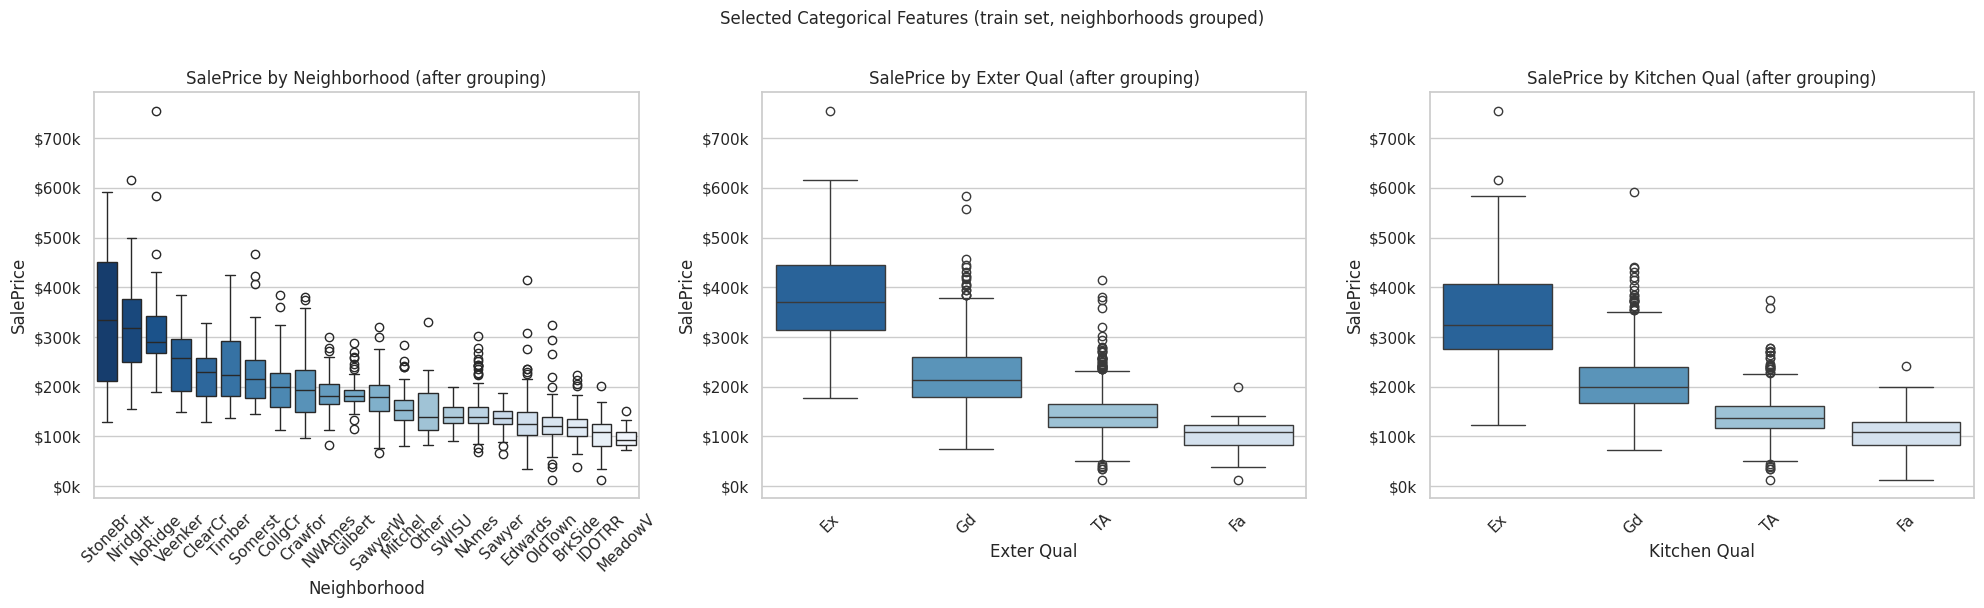

In [21]:
CAT_SEL = ["Neighborhood", "Exter Qual", "Kitchen Qual"]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, col in zip(axes, CAT_SEL):
    plot_df = pd.DataFrame({col: X_train_sel[col].fillna("Unknown"),
                             "SalePrice": y_train})
    order = (plot_df.groupby(col)["SalePrice"]
             .median().sort_values(ascending=False).index)
    sns.boxplot(data=plot_df, x=col, y="SalePrice",
                order=order, ax=ax, palette="Blues_r")
    ax.set_title(f"SalePrice by {col} (after grouping)")
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
    ax.tick_params(axis="x", rotation=45)

plt.suptitle("Selected Categorical Features (train set, neighborhoods grouped)",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

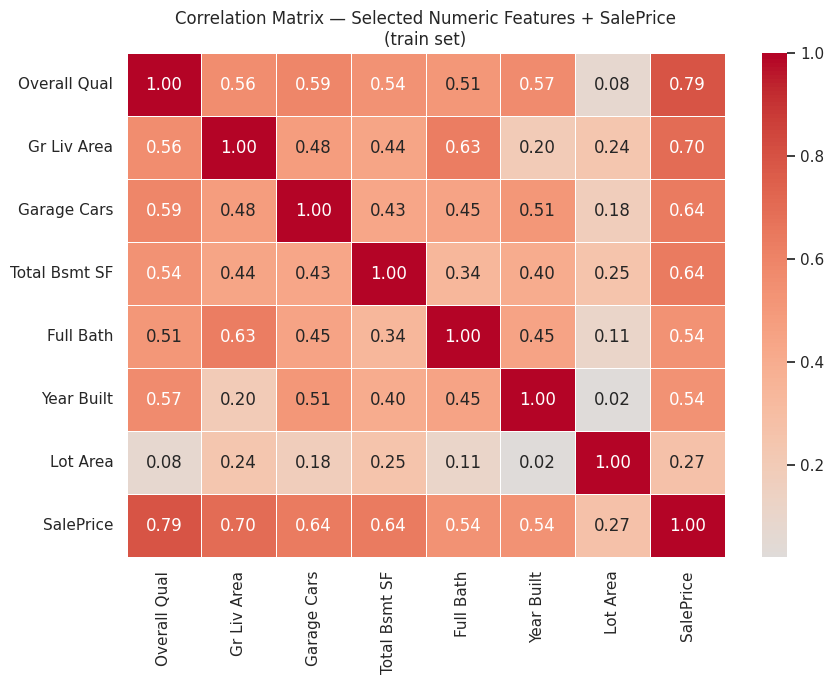

⚠️ High correlation between selected features (|r| > 0.6):
  Gr Liv Area × Full Bath = 0.63


In [22]:
heat_data = (
    X_train_sel[NUMERIC_SEL]
    .apply(lambda c: c.fillna(0))
    .assign(SalePrice=y_train)
    .corr().round(2)
)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(heat_data, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, ax=ax)
ax.set_title("Correlation Matrix — Selected Numeric Features + SalePrice\n(train set)")
plt.tight_layout()
plt.show()

# Multicollinearity check
feat_corr = heat_data.drop(columns="SalePrice").drop(index="SalePrice")
pairs = []
for i in range(len(feat_corr.columns)):
    for j in range(i+1, len(feat_corr.columns)):
        r = abs(feat_corr.iloc[i, j])
        if r > 0.6:
            pairs.append((feat_corr.columns[i], feat_corr.columns[j], round(r, 3)))
if pairs:
    print("⚠️ High correlation between selected features (|r| > 0.6):")
    for a, b, r in pairs:
        print(f"  {a} × {b} = {r}")
else:
    print("✅ No multicollinearity concern (no pair |r| > 0.6) among selected features.")


In [23]:
NUMERIC_FEATURES  = ["Overall Qual","Gr Liv Area","Garage Cars",
                     "Total Bsmt SF","Full Bath","Year Built","Lot Area"]
QUALITY_ORDER     = ["Po","Fa","TA","Gd","Ex"]
ORDINAL_FEATURES  = ["Exter Qual","Kitchen Qual"]
NOMINAL_FEATURES  = ["Neighborhood"]

assert (set(NUMERIC_FEATURES + ORDINAL_FEATURES + NOMINAL_FEATURES)
        == set(SELECTED_FEATURES)), "Feature groups must cover all selected features"

# Numeric: constant fill 0 (both nulls are structural absences) + scale
numeric_branch = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
    ("scaler",  StandardScaler()),
])
# Ordinal: mode fill + ordered integer encoding + scale
ordinal_branch = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(
        categories=[QUALITY_ORDER] * len(ORDINAL_FEATURES),
        handle_unknown="use_encoded_value",
        unknown_value=-1)),
    ("scaler",  StandardScaler()),
])
# Nominal: mode fill + one-hot (handle_unknown=ignore for unseen at inference)
nominal_branch = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_branch, NUMERIC_FEATURES),
    ("ord", ordinal_branch, ORDINAL_FEATURES),
    ("nom", nominal_branch, NOMINAL_FEATURES),
])

print("✅ Preprocessor assembled")
print(f"  num ({len(NUMERIC_FEATURES)} cols): constant(0) → StandardScaler")
print(f"  ord ({len(ORDINAL_FEATURES)} cols): mode → OrdinalEncoder{QUALITY_ORDER} → StandardScaler")
print(f"  nom ({len(NOMINAL_FEATURES)} col) : mode → OneHotEncoder")

# Final null check on narrowed splits
print("\nNull counts in selected features after grouping:")
for feat in SELECTED_FEATURES:
    n = X_train_sel[feat].isnull().sum()
    flag = " ← handled by constant(0) imputer" if n > 0 else " ✅"
    print(f"  {feat:<20}  train_nulls={n}{flag}")



✅ Preprocessor assembled
  num (7 cols): constant(0) → StandardScaler
  ord (2 cols): mode → OrdinalEncoder['Po', 'Fa', 'TA', 'Gd', 'Ex'] → StandardScaler
  nom (1 col) : mode → OneHotEncoder

Null counts in selected features after grouping:
  Overall Qual          train_nulls=0 ✅
  Gr Liv Area           train_nulls=0 ✅
  Garage Cars           train_nulls=1 ← handled by constant(0) imputer
  Total Bsmt SF         train_nulls=1 ← handled by constant(0) imputer
  Full Bath             train_nulls=0 ✅
  Year Built            train_nulls=0 ✅
  Lot Area              train_nulls=0 ✅
  Neighborhood          train_nulls=0 ✅
  Exter Qual            train_nulls=0 ✅
  Kitchen Qual          train_nulls=0 ✅


In [24]:
model_specs = {
    "RandomForest": RandomForestRegressor(
        n_estimators=300, max_depth=None, min_samples_split=5,
        min_samples_leaf=2, max_features="sqrt",
        random_state=42, n_jobs=-1),
    "GradientBoosting": GradientBoostingRegressor(
        n_estimators=400, learning_rate=0.05, max_depth=4,
        subsample=0.8, min_samples_leaf=5, random_state=42),
}

results = {}
for model_name, estimator in model_specs.items():
    pipe = Pipeline([("preprocessor", preprocessor), ("model", estimator)])
    pipe.fit(X_train_sel, y_train)   # preprocessor .fit() only sees X_train_sel

    tr_pred  = pipe.predict(X_train_sel)
    val_pred = pipe.predict(X_val_sel)

    tr_rmse  = np.sqrt(mean_squared_error(y_train, tr_pred))
    val_rmse = np.sqrt(mean_squared_error(y_val,   val_pred))
    gap      = (val_rmse - tr_rmse) / tr_rmse * 100

    results[model_name] = dict(
        pipeline=pipe,
        train_rmse=tr_rmse,  val_rmse=val_rmse,
        train_r2=r2_score(y_train, tr_pred),
        val_r2  =r2_score(y_val,   val_pred),
    )
    r = results[model_name]
    print(f"\n  {model_name}")
    print(f"  Train RMSE: ${tr_rmse:>9,.0f}   R²={r['train_r2']:.4f}")
    print(f"  Val   RMSE: ${val_rmse:>9,.0f}   R²={r['val_r2']:.4f}")
    print(f"  Gap: +{gap:.1f}%")


  RandomForest
  Train RMSE: $   19,609   R²=0.9364
  Val   RMSE: $   29,655   R²=0.8728
  Gap: +51.2%

  GradientBoosting
  Train RMSE: $   14,359   R²=0.9659
  Val   RMSE: $   27,504   R²=0.8906
  Gap: +91.6%


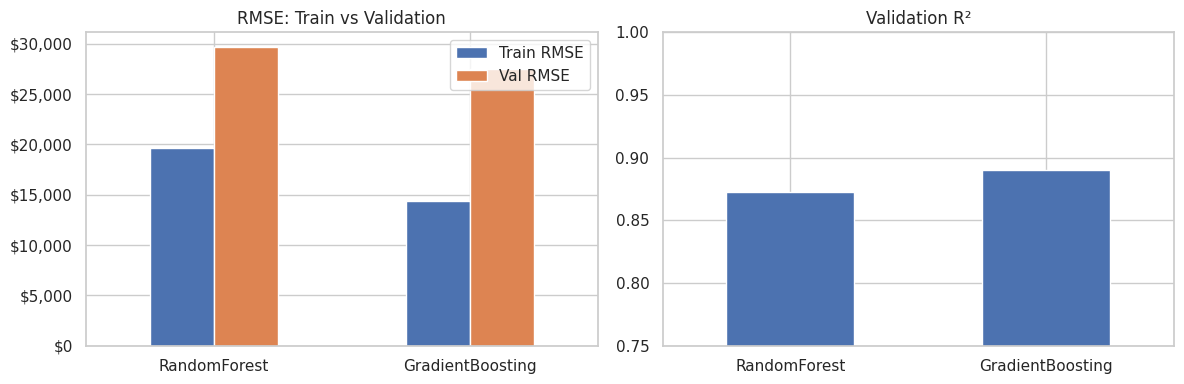


🏆 Best: GradientBoosting  Val RMSE=$27,504  R²=0.8906


In [25]:
compare_df = pd.DataFrame({
    name: {"Train RMSE": r["train_rmse"], "Val RMSE": r["val_rmse"],
           "Val R²": r["val_r2"]}
    for name, r in results.items()
}).T

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
compare_df[["Train RMSE","Val RMSE"]].plot(kind="bar", ax=axes[0],
                                            color=[BLUE, CORAL])
axes[0].set_title("RMSE: Train vs Validation")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
axes[0].tick_params(axis="x", rotation=0)

compare_df[["Val R²"]].plot(kind="bar", ax=axes[1], color=BLUE, legend=False)
axes[1].set_title("Validation R²")
axes[1].set_ylim(0.75, 1.0)
axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

best_name     = min(results, key=lambda k: results[k]["val_rmse"])
best_pipeline = results[best_name]["pipeline"]
best_res      = results[best_name]
print(f"\n🏆 Best: {best_name}  Val RMSE=${best_res['val_rmse']:,.0f}  R²={best_res['val_r2']:.4f}")

  FINAL TEST SET EVALUATION — run once, never again
  Model     : GradientBoosting
  Test RMSE : $26,065
  Test R²   : 0.9003

  ✏️ For your project card:
     Best model: GradientBoosting | Test RMSE: $26,065 | R²: 0.9003


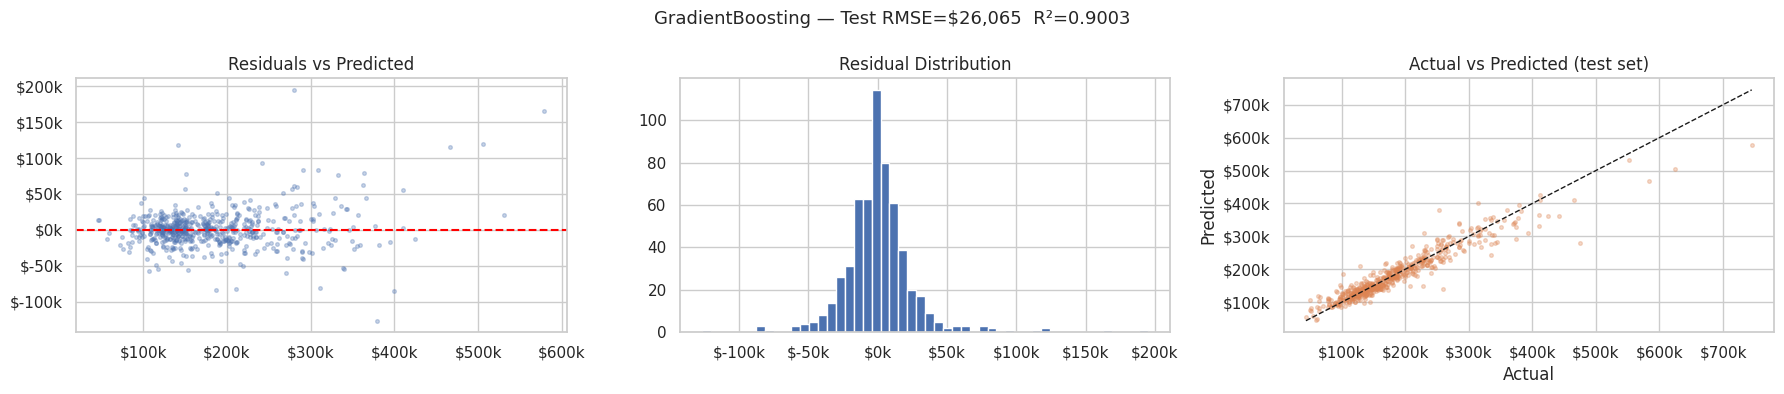

In [26]:
test_pred = best_pipeline.predict(X_test_sel)
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
test_r2   = r2_score(y_test, test_pred)

print("=" * 52)
print("  FINAL TEST SET EVALUATION — run once, never again")
print("=" * 52)
print(f"  Model     : {best_name}")
print(f"  Test RMSE : ${test_rmse:,.0f}")
print(f"  Test R²   : {test_r2:.4f}")
print(f"\n  ✏️ For your project card:")
print(f"     Best model: {best_name} | Test RMSE: ${test_rmse:,.0f} | R²: {test_r2:.4f}")

residuals = y_test - test_pred
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].scatter(test_pred, residuals, alpha=0.3, s=7, color=BLUE)
axes[0].axhline(0, color="red", ls="--")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
axes[0].set_title("Residuals vs Predicted")

axes[1].hist(residuals, bins=50, color=BLUE, edgecolor="white")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
axes[1].set_title("Residual Distribution")

axes[2].scatter(y_test, test_pred, alpha=0.3, s=7, color=CORAL)
mn, mx = y_test.min(), y_test.max()
axes[2].plot([mn, mx], [mn, mx], "k--", lw=1)
axes[2].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
axes[2].set_xlabel("Actual")
axes[2].set_ylabel("Predicted")
axes[2].set_title("Actual vs Predicted (test set)")

plt.suptitle(f"{best_name} — Test RMSE=${test_rmse:,.0f}  R²={test_r2:.4f}",
             fontsize=13)
plt.tight_layout()
plt.show()


Permutation Importance on Val Set (|mean ΔRMSE when shuffled|):
  Overall Qual          $ 21,163  ████████████████████████████
  Gr Liv Area           $ 15,490  ████████████████████
  Total Bsmt SF         $  9,356  ████████████
  Year Built            $  4,554  ██████
  Lot Area              $  3,618  ████
  Neighborhood          $  2,963  ███
  Garage Cars           $  2,532  ███
  Kitchen Qual          $  1,810  ██
  Full Bath             $  1,600  ██
  Exter Qual            $    888  █


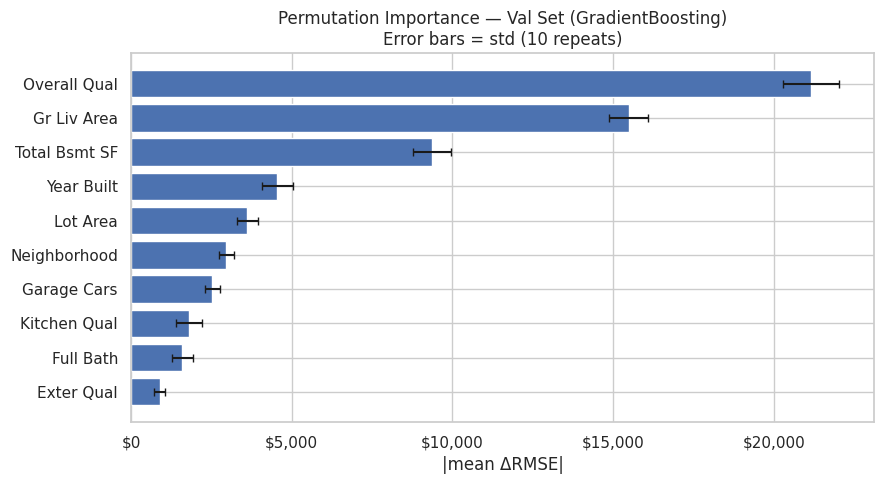

In [27]:
perm = permutation_importance(
    best_pipeline, X_val_sel, y_val,
    n_repeats=10, random_state=42,
    scoring="neg_root_mean_squared_error", n_jobs=-1)

perm_means = (pd.Series(np.abs(perm.importances_mean), index=SELECTED_FEATURES)
              .sort_values(ascending=False))
perm_stds  = pd.Series(perm.importances_std, index=SELECTED_FEATURES)

print("Permutation Importance on Val Set (|mean ΔRMSE when shuffled|):")
for feat, imp in perm_means.items():
    bar = "█" * int(imp / perm_means.max() * 28)
    print(f"  {feat:<20}  ${imp:>7,.0f}  {bar}")

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(range(len(perm_means)), perm_means.sort_values().values,
        xerr=perm_stds.reindex(perm_means.sort_values().index).values,
        color=BLUE, capsize=3)
ax.set_yticks(range(len(perm_means)))
ax.set_yticklabels(perm_means.sort_values().index)
ax.set_xlabel("|mean ΔRMSE|")
ax.set_title(f"Permutation Importance — Val Set ({best_name})\nError bars = std (10 repeats)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.tight_layout()
plt.show()

In [28]:
price_by_nbhd    = (df.groupby("Neighborhood")["SalePrice"]
                    .mean().round(0).astype(int).to_dict())
price_by_qual    = {str(k): int(v) for k, v in
                    df.groupby("Overall Qual")["SalePrice"].mean().round(0).items()}
price_by_exter   = (df.groupby("Exter Qual")["SalePrice"]
                    .mean().round(0).astype(int).to_dict())
price_by_kitchen = (df.groupby("Kitchen Qual")["SalePrice"]
                    .mean().round(0).astype(int).to_dict())

df["_psf"] = df["SalePrice"] / df["Gr Liv Area"]

training_stats = {
    "median_price": int(df["SalePrice"].median()),
    "mean_price":   int(df["SalePrice"].mean()),
    "price_p10":    int(df["SalePrice"].quantile(0.10)),
    "price_p25":    int(df["SalePrice"].quantile(0.25)),
    "price_p75":    int(df["SalePrice"].quantile(0.75)),
    "price_p90":    int(df["SalePrice"].quantile(0.90)),
    "price_std":    int(df["SalePrice"].std()),
    "avg_price_by_neighborhood":  price_by_nbhd,
    "avg_price_by_quality":       price_by_qual,
    "avg_price_by_exter_qual":    price_by_exter,
    "avg_price_by_kitchen_qual":  price_by_kitchen,
    "price_per_sqft_median":      float(round(df["_psf"].median(), 2)),
    "price_per_sqft_p25":         float(round(df["_psf"].quantile(0.25), 2)),
    "price_per_sqft_p75":         float(round(df["_psf"].quantile(0.75), 2)),
    "top_5_most_expensive_neighborhoods":  [n for n, _ in
        sorted(price_by_nbhd.items(), key=lambda x: x[1], reverse=True)[:5]],
    "top_5_most_affordable_neighborhoods": [n for n, _ in
        sorted(price_by_nbhd.items(), key=lambda x: x[1])[:5]],
    "valid_neighborhoods":   sorted(COMMON_NEIGHBORHOODS + ["Other"]),
    "rare_neighborhoods":    sorted(RARE_NEIGHBORHOODS),
    "rare_threshold":        RARE_THRESHOLD,
    "valid_exter_quals":     sorted(df["Exter Qual"].dropna().unique().tolist()),
    "valid_kitchen_quals":   sorted(df["Kitchen Qual"].dropna().unique().tolist()),
    "feature_importance":    {f: float(round(v, 4)) for f, v in perm_means.items()},
    "model_type":        best_name,
    "selected_features": SELECTED_FEATURES,
    "numeric_features":  NUMERIC_FEATURES,
    "ordinal_features":  ORDINAL_FEATURES,
    "nominal_features":  NOMINAL_FEATURES,
    "quality_order":     QUALITY_ORDER,
    "test_rmse":         int(test_rmse),
    "test_r2":           float(round(test_r2, 4)),
    "val_rmse":          int(best_res["val_rmse"]),
    "val_r2":            float(round(best_res["val_r2"], 4)),
    "train_rows":        int(len(X_train_sel)),
    "dataset":           "Ames Housing CSV (Iowa, 2,930 residential sales 2006-2010)",
    "total_rows":        int(len(df)),
    "feature_count":     int(len(SELECTED_FEATURES)),
}

print(f"✅ Stats ready — neighborhoods: {len(training_stats['valid_neighborhoods'])}")
print(f"   Top 5 expensive : {training_stats['top_5_most_expensive_neighborhoods']}")
print(f"   Top 5 affordable: {training_stats['top_5_most_affordable_neighborhoods']}")



✅ Stats ready — neighborhoods: 22
   Top 5 expensive : ['NoRidge', 'StoneBr', 'NridgHt', 'GrnHill', 'Veenker']
   Top 5 affordable: ['MeadowV', 'IDOTRR', 'BrDale', 'OldTown', 'BrkSide']


In [29]:
Path("saved_model").mkdir(exist_ok=True)

model_path = "saved_model/trained_house_price_model.pkl"
stats_path = "saved_model/training_statistics.json"

joblib.dump(best_pipeline, model_path)
with open(stats_path, "w") as f:
    json.dump(training_stats, f, indent=2)

print(f"✅ Saved: {model_path}")
print(f"✅ Saved: {stats_path}")

✅ Saved: saved_model/trained_house_price_model.pkl
✅ Saved: saved_model/training_statistics.json


In [30]:
reloaded = joblib.load(model_path)

# Test input uses EXACT CSV column names (with spaces)
test_house = pd.DataFrame([{
    "Overall Qual": 7, "Gr Liv Area": 1500.0, "Garage Cars": 2.0,
    "Total Bsmt SF": 800.0, "Full Bath": 2, "Year Built": 2000,
    "Lot Area": 8500.0, "Neighborhood": "CollgCr",
    "Exter Qual": "Gd", "Kitchen Qual": "Gd",
}])

pred_check = reloaded.predict(test_house)[0]
expected   = 155000 < pred_check < 230000
print(f"\n✅ Sanity check: qual=7, 1500sqft, 2-car garage, CollgCr, Gd quality, yr 2000")
print(f"   Predicted: ${pred_check:,.0f}  {'✅ in expected range $155k-$230k' if expected else '⚠️ outside expected range'}")

print()
print("=" * 60)
print("  TRAINING COMPLETE")
print("=" * 60)
print(f"  Dataset   : Ames Housing CSV ({len(df):,} rows)")
print(f"  Features  : {len(SELECTED_FEATURES)} selected from 80")
print(f"  Nbhd grp  : {len(RARE_NEIGHBORHOODS)} rare → 'Other' | {len(COMMON_NEIGHBORHOODS)} kept")
print(f"  Model     : {best_name}")
print(f"  Val       : RMSE=${best_res['val_rmse']:,}  R²={best_res['val_r2']:.4f}")
print(f"  Test      : RMSE=${test_rmse:,}  R²={test_r2:.4f}")
print()
print("  📥 Download from Colab Files panel (left sidebar):")
print("     saved_model/trained_house_price_model.pkl")
print("     saved_model/training_statistics.json")
print("  📁 Place both in:  backend/saved_model/")


✅ Sanity check: qual=7, 1500sqft, 2-car garage, CollgCr, Gd quality, yr 2000
   Predicted: $188,441  ✅ in expected range $155k-$230k

  TRAINING COMPLETE
  Dataset   : Ames Housing CSV (2,930 rows)
  Features  : 10 selected from 80
  Nbhd grp  : 7 rare → 'Other' | 21 kept
  Model     : GradientBoosting
  Val       : RMSE=$27,504.341933507356  R²=0.8906
  Test      : RMSE=$26,064.552565967606  R²=0.9003

  📥 Download from Colab Files panel (left sidebar):
     saved_model/trained_house_price_model.pkl
     saved_model/training_statistics.json
  📁 Place both in:  backend/saved_model/
